<a href="https://colab.research.google.com/github/KarlaMichelleSorianoSanhez/Procesos-estocasticos/blob/main/Serpientes_y_escaleras_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MATRIZ FUNDAMENTAL

# SERPIENTES Y ESCALERAS

**Nombre: Karla Michelle Soriano Sánchez**

**Objetivo** : Analizar el juego de serpientes y escaleras utilizando cadenas de Markov absorbentes y simulación Monte Carlo, con el propósito de determinar el número promedio de tiradas necesarias para finalizar el juego.

Posteriormente, se compararán los resultados analíticos con los resultados experimentales obtenidos mediante simulación.


**Instrucciones**:  Resolver analíticamente y por simulación en un cuaderno de Jupyter Notebook.

¿Cuál es el número promedio de tiradas necesarias para terminar el juego de serpientes y escaleras en el tablero de la imagen adjunta?

Resolver a detalle.

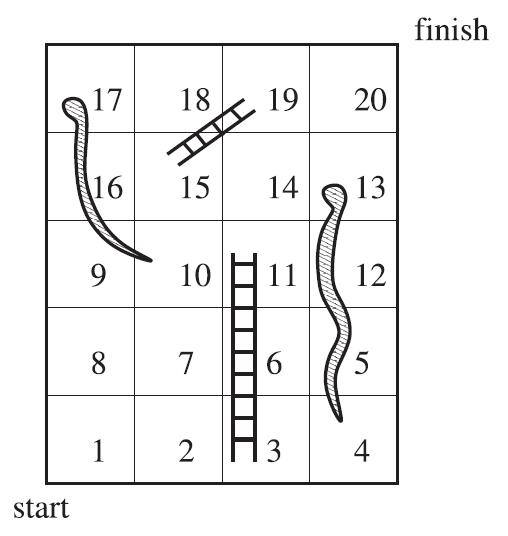




El juego de serpientes y escaleras puede modelarse mediante una cadena de Markov, ya que la posición futura del jugador depende únicamente de la casilla en la que se encuentra actualmente y del resultado obtenido al lanzar el dado.

En este modelo, cada casilla del tablero representa un estado del sistema y las probabilidades de transición se determinan considerando todos los posibles resultados del dado.

Además, debido a que el juego termina cuando el jugador alcanza la última casilla, el sistema corresponde a una cadena de Markov absorbente.

En esta práctica se construirá la matriz de transición del juego, posteriormente se obtendrá la matriz fundamental y finalmente se realizará una simulación Monte Carlo para validar los resultados obtenidos analíticamente.


## SOLUCION ANALITICA

### Descripción del tablero

El tablero del juego está formado por $20$ casillas numeradas del $1$ al $20$.

La casilla $20$ corresponde al estado absorbente, ya que una vez que el jugador llega a dicha casilla el juego termina.

Las reglas especiales del tablero son:

* Escaleras: Las escaleras permiten avanzar automáticamente a una casilla superior:

$$
3 \longrightarrow 11
$$

$$
15 \longrightarrow 19
$$

* Serpientes: Las serpientes obligan al jugador a retroceder a una casilla inferior:

$$
13 \longrightarrow 4
$$

$$
17 \longrightarrow 10
$$



### Construcción de la matriz de transición

Sea

$$
P=(P_{ij})
$$

la matriz de transición asociada al juego.

Cada entrada $P_{ij}$ representa la probabilidad de pasar de la casilla $i$ a la casilla $j$ en un solo movimiento.

Matemáticamente:

$$
P_{ij}=P(X_{n+1}=j \mid X_n=i)
$$

donde:

- $X_n$ representa la posición del jugador en el paso $n$.
- $X_{n+1}$ representa la posición después de realizar un lanzamiento.


El juego puede modelarse mediante una cadena de Markov absorbente debido a que:

- El siguiente movimiento depende únicamente de la posición actual.
- Existe un estado absorbente (casilla \(20\)).
- Las probabilidades de transición permanecen constantes.

\vspace{0.5cm}

## Probabilidades de transición

Para cada casilla transitoria \(i\), los posibles resultados del dado son:

$$
1,2,3,4,5,6
$$

Como el dado es justo, cada resultado ocurre con probabilidad:

$$
\frac{1}{6}
$$

Si el jugador se encuentra en la casilla \(i\), entonces el movimiento tentativo se calcula mediante:

$$
\text{destino}_{\text{tentativo}}
=
i+\text{dado}
$$

Posteriormente se revisan las reglas especiales del tablero.

- Si el jugador cae en una escalera, avanza automáticamente.
- Si el jugador cae en una serpiente, retrocede automáticamente.

Además, si el movimiento supera la casilla \(20\), el jugador pasa directamente al estado absorbente:

$$
j=20
$$

\vspace{0.5cm}

## Procedimiento para construir la matriz

La construcción de la matriz de transición se realiza siguiendo los pasos:

1. Lanzar el dado.
2. Avanzar el número de casillas indicado.
3. Verificar si la nueva casilla contiene una serpiente o una escalera.
4. Aplicar automáticamente el salto correspondiente.
5. Registrar la probabilidad de transición obtenida.

Repitiendo este procedimiento para todas las casillas del tablero se obtiene la matriz de transición completa.

\vspace{0.5cm}

## Clasificación de estados

La matriz de transición presenta:

- Estados transitorios:

$$
1,2,3,\dots,19
$$

ya que desde estas casillas todavía es posible continuar jugando.

- Estado absorbente:

$$
20
$$

porque una vez alcanzado dicho estado, el proceso termina y ya no es posible salir de él.

Por esta razón:

$$
P_{20,20}=1
$$

lo cual indica que el sistema permanece permanentemente en la casilla final.

In [61]:
import numpy as np
import sympy as sp

In [62]:
def matriz_transicion():
  #configuracion del tablero del juego (casillas )
    n = 20

    #Numero de caras del dado
    dado = 6

    # Saltos: escaleras y serpientes
    salto = {3: 11, 15: 19, 13: 5, 17: 7}


    #inicializamos la matriz
    P = np.zeros((n, n))
    P[n-1, n-1] = 1  # estado absorbente


    #construccion de probabilidades
    for i in range(1, n):
        for k in range(1, dado + 1):
            pos = min(i + k, n)          # si se pasa → 20
            pos = salto.get(pos, pos)    # aplicar salto si existe
            P[i-1, pos-1] += 1/dado

    return P

In [63]:
# imprimir la matriz
P = matriz_transicion()
print("Matriz de transición:")
sp.Matrix(P)

Matriz de transición:


Matrix([
[0.0, 0.166666666666667, 0.0, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.166666666666667,               0.0,               0.0,               0.0, 0.166666666666667,               0.0, 0.0,               0.0, 0.0,               0.0, 0.0,               0.0,               0.0,               0.0],
[0.0,               0.0, 0.0, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.166666666666667,               0.0,               0.0, 0.166666666666667,               0.0, 0.0,               0.0, 0.0,               0.0, 0.0,               0.0,               0.0,               0.0],
[0.0,               0.0, 0.0, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.166666666666667,               0.0,               0.0,               0.0, 0.0,               0.0, 0.0,               0.0, 0.0,               0.0,               0.0,               0.0],
[0.0,               0.0, 0.0,               0.0, 0.1666

In [64]:
#             1,   2, 3,   4,   5,   6,   7,   8,   9,  10,  11, 12, 13, 14, 15, 16, 17, 18, 19, 20
P=sp.Matrix([[0, 1/6, 0, 1/6, 1/6, 1/6, 1/6,   0,   0,   0, 1/6,  0,  0,  0,  0,  0,  0,  0,  0, 0],
             [0,   0, 0, 1/6, 1/6, 1/6, 1/6, 1/6,   0,   0, 1/6,  0,  0,  0,  0,  0,  0,  0,  0, 0],
             [0,   0, 0, 1/6,   0,   0,   0,   0,   0, 1/6,   0, 1/6, 0,1/6,  0,1/6,  0,  0,1/6, 0],#3_11
             [0,   0, 0,   0, 1/6, 1/6, 1/6, 1/6, 1/6, 1/6,   0,   0, 0,  0,  0,  0,  0,  0,  0, 0],
             [0,   0, 0,   0,   0, 1/6, 1/6, 1/6, 1/6, 1/6, 1/6,  0,  0,  0,  0,  0,  0,  0,  0, 0],
             [0,   0, 0,   0,   0,   0, 1/6, 1/6, 1/6, 1/6, 1/6, 1/6, 0,  0,  0,  0,  0,  0,  0, 0],#6
             #7
             [0,   0, 0, 1/6,   0,   0,   0, 1/6, 1/6, 1/6, 1/6, 1/6, 0,  0,  0,  0,  0,  0,  0, 0],
              #8
             [0,   0, 0, 1/6,   0,   0,   0,   0, 1/6, 1/6, 1/6, 1/6, 0,1/6,  0,  0,  0,  0,  0, 0],
              #9
             [0,   0, 0, 1/6,   0,   0,   0,   0,   0, 1/6, 1/6, 1/6, 0,1/6,  0,  0,  0,  0,1/6, 0],
              #10
             [0,   0, 0, 1/6,   0,   0,   0,   0,   0,   0, 1/6, 1/6, 0,1/6,  0,1/6,  0,  0,1/6,  0],

              #11
             [0,   0, 0, 1/6,   0,   0,   0,   0,   0, 1/6,   0, 1/6, 0,1/6,  0,1/6,  0,  0,1/6, 0],
              #12
             [0,   0, 0, 1/6,   0,   0,   0,   0,   0, 1/6,   0,   0, 0,1/6,  0,1/6,  0,1/6,1/6, 0],
              #13 es 4
             [0,   0, 0,   0, 1/6, 1/6, 1/6, 1/6, 1/6, 1/6,   0,   0, 0,  0,  0,  0,  0,  0,  0, 0],
              #14
             [0,   0, 0,   0,   0,   0,   0,   0,   0, 1/6,   0,   0, 0,  0,  0,1/6,  0,1/6,2/6,1/6],
              #15
             [0,   0, 0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 0,  0,  0,  0,  0,  0,  0,  1],
              #16
             [0,   0, 0,   0,   0,   0,   0,   0,   0, 1/6,   0,   0, 0,  0,  0,  0,  0,1/6,1/6,3/6],
              #17 es 10
             [0,   0, 0, 1/6,   0,   0,   0,   0,   0,   0, 1/6, 1/6, 0,1/6,  0,1/6,  0,  0,1/6,  0],
              #18
             [0,   0, 0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 0,  0,  0,  0,  0,  0,1/6,5/6],
              #19
             [0,   0, 0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 0,  0,  0,  0,  0,  0,  0,  1],
              #20
             [0,   0, 0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 0,  0,  0,  0,  0,  0,  0,  1]])
#             1,   2, 3,   4,   5,   6,   7,   8,   9,  10,  11,  12, 13, 14, 15, 16, 17, 18, 19, 20


### Interpretación de la matriz de transición

La matriz obtenida es de tamaño:

$$
20 \times 20
$$

Cada fila representa el estado actual del jugador y cada columna representa el estado al que puede transitar después de una tirada.

Por ejemplo:

$$
P_{ij}
$$

representa la probabilidad de pasar de la casilla \(i\) a la casilla \(j\).

La última fila corresponde al estado absorbente:

$$
P_{20,20}=1
$$

ya que una vez alcanzada la casilla 20 el juego finaliza y el proceso permanece permanentemente en dicho estado.

## Forma canónica de la matriz


Una vez construida la matriz de transición \(P\), procedemos a escribirla en su forma canónica.

La forma canónica de una cadena de Markov absorbente organiza los estados de manera que primero aparecen los estados transitorios y al final los estados absorbentes.


En este problema:

- Estados transitorios:

$$
1,2,3,\dots,19
$$

- Estado absorbente:

$$
20
$$

Por esta razón, la matriz puede escribirse en la forma:

$$
P=
\begin{pmatrix}
Q & R \\
0 & I
\end{pmatrix}
$$

donde:

- $Q$: contiene las probabilidades de transición entre estados transitorios.
- $R$: contiene las probabilidades de pasar de un estado transitorio al estado absorbente.
- $I$: corresponde a la matriz identidad asociada al estado absorbente.
- $0$: representa una matriz de ceros.

En este problema:

- Las casillas 1 a 19 son estados transitorios.
- La casilla 20 es el estado absorbente.


Para simplificar el procedimiento utilizamos una función que transforma automáticamente la matriz $P$ a su forma canónica.




In [65]:
import sympy as sp

def canonica(P):
    """
    Calcula la descomposición canónica de una matriz de transición P.

    Parámetros:
    P : matriz de transición (SymPy)

    Retorna:
    - Matriz reorganizada en forma canónica
    """

    n = P.shape[0]

    # --------------------------------------------------
    # Paso 1: Función de alcanzabilidad R(i)
    # --------------------------------------------------
    # Devuelve los estados alcanzables desde i
    def R(i):
        s = {i}
        stack = [i]

        while stack:
            u = stack.pop()
            for v in range(n):
                if P[u,v] != 0 and v not in s:
                    s.add(v)
                    stack.append(v)

        return s

    # --------------------------------------------------
    # Paso 2: Encontrar clases de comunicación
    # --------------------------------------------------
    no = set(range(n))
    clases = []

    while no:
        i = next(iter(no))
        Ri = R(i)

        # Estados que se comunican con i
        c = {j for j in Ri if i in R(j)}

        clases.append(c)
        no -= c

    print("Clases de comunicación:")
    for c in clases:
        print(c)

    # --------------------------------------------------
    # Paso 3: Identificar clases cerradas (recurrentes)
    # --------------------------------------------------
    T = set(range(n))
    for c in clases:
        if all(P[i,j]==0 or j in c for i in c for j in range(n)):
            T -= c

    T = list(T)
    Rr = [i for c in clases for i in c if i not in T]

    orden = T + Rr
    return P.extract(orden, orden)

    # --------------------------------------------------
    # Paso 4: Estados transitorios
    # --------------------------------------------------
    T = list(T)  # recurrentes
    Rr = [i for c in clases for i in c if i not in T]

    print("\nEstados recurrentes:", T)
    print("Estados transitorios:", Rr)

    # --------------------------------------------------
    # Paso 5: Orden final
    # --------------------------------------------------
    orden = T + Rr

    print("\nOrden de estados:", orden)

    # --------------------------------------------------
    # Paso 6: Matriz canónica
    # --------------------------------------------------
    P_can = P.extract(orden, orden)

    print("\nMatriz en forma canónica:")
    sp.pprint(P_can)

    return P_can

Aplicamos la función a la matriz de transición:

In [66]:
canonica (P)

Clases de comunicación:
{0}
{1}
{2}
{3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 15}
{12}
{14}
{16}
{17}
{18}
{19}


Matrix([
[0, 0.166666666666667, 0, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.166666666666667,                 0,                 0,                 0, 0.166666666666667,                 0, 0,                 0, 0,                 0, 0,                 0,                 0,                 0],
[0,                 0, 0, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.166666666666667,                 0,                 0, 0.166666666666667,                 0, 0,                 0, 0,                 0, 0,                 0,                 0,                 0],
[0,                 0, 0, 0.166666666666667,                 0,                 0,                 0,                 0,                 0, 0.166666666666667,                 0, 0.166666666666667, 0, 0.166666666666667, 0, 0.166666666666667, 0,                 0, 0.166666666666667,                 0],
[0,                 0, 0,                 0, 0.166666666666667, 0.166666666666667, 0.

La matriz obtenida corresponde a la representación canónica de la cadena de Markov absorbente.

A continuación extraemos la submatriz \(Q\), la cual contiene únicamente las probabilidades de transición entre estados transitorios.

En este caso:

$$
Q=P_c(1:19,1:19)
$$

Posteriormente construimos la matriz identidad \(I\) de dimensión \(19 \times 19\), ya que existen \(19\) estados transitorios.

In [67]:
# Extraer submatriz Q
Q = P[:19,:19]

print("Submatriz Q:")

Q

Submatriz Q:


Matrix([
[0, 0.166666666666667, 0, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.166666666666667,                 0,                 0,                 0, 0.166666666666667,                 0, 0,                 0, 0,                 0, 0,                 0,                 0],
[0,                 0, 0, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.166666666666667,                 0,                 0, 0.166666666666667,                 0, 0,                 0, 0,                 0, 0,                 0,                 0],
[0,                 0, 0, 0.166666666666667,                 0,                 0,                 0,                 0,                 0, 0.166666666666667,                 0, 0.166666666666667, 0, 0.166666666666667, 0, 0.166666666666667, 0,                 0, 0.166666666666667],
[0,                 0, 0,                 0, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.

La matriz:

$$
I-Q
$$

es fundamental en el estudio de cadenas absorbentes, ya que permite calcular la matriz fundamental del sistema.

In [68]:

I=np.identity(19)
I-Q

Matrix([
[1.0, -0.166666666666667,   0, -0.166666666666667, -0.166666666666667, -0.166666666666667, -0.166666666666667,                  0,                  0,                  0, -0.166666666666667,                  0,   0,                  0,   0,                  0,   0,                  0,                  0],
[  0,                1.0,   0, -0.166666666666667, -0.166666666666667, -0.166666666666667, -0.166666666666667, -0.166666666666667,                  0,                  0, -0.166666666666667,                  0,   0,                  0,   0,                  0,   0,                  0,                  0],
[  0,                  0, 1.0, -0.166666666666667,                  0,                  0,                  0,                  0,                  0, -0.166666666666667,                  0, -0.166666666666667,   0, -0.166666666666667,   0, -0.166666666666667,   0,                  0, -0.166666666666667],
[  0,                  0,   0,                1.0, -0.166666666666667,

### Matriz fundamental

La matriz fundamental se define mediante:

$$
N=(I-Q)^{-1}
$$

Esta matriz es una de las herramientas más importantes en cadenas de Markov absorbentes.

La interpretación probabilística de $N$ es la siguiente:

- Cada entrada $N_{ij}$representa el número esperado de veces que el proceso visitará el estado $j$comenzando desde el estado $i$, antes de ser absorbido.

Además, la suma de cada fila proporciona el número esperado de pasos necesarios para llegar al estado absorbente.

In [69]:
N=(I-Q)**(-1)
N

Matrix([
[1.0, 0.166666666666667,   0,   0.66897572306483,  0.305940398288583,  0.356930464670013,  0.416418875448349,   0.31915535468974,  0.344570136026919, 0.706598709071859,  0.602713434143688,  0.457731162341761,   0, 0.405128132712328,   0, 0.362028573044939,   0, 0.204147978016505, 0.581341043011721],
[  0,               1.0,   0,  0.647471733083607,  0.274578622180601,  0.320341725877368,  0.373732013523596,  0.436020682444195,  0.342024129518228, 0.700619124603555,  0.574552716357924,  0.457881732054144,   0, 0.418516397496341,   0, 0.358594995085327,   0, 0.205832187439302, 0.579422946675194],
[  0,                 0, 1.0,  0.390190673625065, 0.0650317789375108, 0.0758704087604293, 0.0885154768871675,  0.103268056368362,  0.120479399096422, 0.521199266353474,  0.162394064400561,  0.345287778644403,   0,  0.37543809414387,   0, 0.400719867257051,   0, 0.186907623340887, 0.581310697896756],
[  0,                 0,   0,    1.4756020316059,  0.245933671934317,  0.286922617256703

Una vez obtenida la matriz fundamental, calculamos el número esperado de tiradas necesarias para finalizar el juego.

Como el jugador inicia en la casilla \(1\), debemos sumar los elementos del primer renglón de la matriz \(F\).

Esto se debe a que dicho renglón representa el número esperado de visitas a cada estado transitorio comenzando desde la casilla inicial.

In [70]:
a = sum(N[0,0:19])
a

6.89834665119790

El resultado obtenido es:

$$
a \approx 6.8983
$$

Por lo tanto, el número promedio de tiradas necesarias para terminar el juego de serpientes y escaleras, comenzando desde la casilla \(1\), es aproximadamente:

$$
6.89 \text{ tiradas}
$$

Este valor representa el tiempo esperado de absorción de la cadena de Markov.